<a href="https://colab.research.google.com/github/agustintamez/Actividades/blob/main/AF7_RNP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AF7: Redes Neuronales Artificiales

#### Hora Clase: N5

**Integrantes del equipo:**
* Agustin Azael Tamez Galaviz 2173925 IMTC
* Diego Antonio Garcia Cardiel 2046605 IMTC
* Luis Angel Araujo Solis 1411762 IMTC
* Zuriel Emiliano Jasso Davila 2177803 IMTC
* Juan Pablo Flores Perez 19033468 IMTC

# 1.- Cargar Librerias.
#### En esta celda importamos TensorFlow y Keras (que contienen el modelo y los datos), junto con Matplotlib para visualizar los resultados.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


# 2.- Cargar Datos.
#### Usamos la función load_data() de Keras para obtener las imágenes de entrenamiento y prueba.

In [ ]:
# Cargar el dataset MNIST
(train_data, train_labels), (test_data, test_labels) = keras.datasets.mnist.load_data()

print(f"Datos de entrenamiento: {train_data.shape}")
print(f"Datos de prueba: {test_data.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Datos de entrenamiento: (60000, 28, 28)
Datos de prueba: (10000, 28, 28)


# 3.- Procesamiento De Datos.
#### Las imágenes son de 28x28 píxeles con valores de 0 a 255. Necesitamos "aplanarlas" para una red feedforward y normalizar los valores al rango [0, 1].


In [ ]:
# Normalizar los valores de los píxeles (0 a 1)
train_data = train_data.astype("float32") / 255
test_data = test_data.astype("float32") / 255

# Aplanamos las imágenes (convertir la matriz 28x28 en un vector de 784)
# Esto se puede hacer también con una capa 'Flatten' en el modelo.
print("Preprocesamiento listo.")

Preprocesamiento listo.


# 4.- Seleccion Y Entrenamiento Del Modelo.
#### Aquí definimos la estructura de la red neuronal. Usaremos una capa de entrada, una capa oculta (puedes ajustar el número de neuronas) y la capa de salida obligatoria con softmax.

In [ ]:
# Definir la estructura de la red neuronal
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)), # Transforma la imagen 2D a 1D
    keras.layers.Dense(128, activation='relu'),   # Capa oculta con 128 neuronas
    keras.layers.Dense(10, activation='softmax')  # Capa de salida (10 dígitos del 0-9)
])

# Configurar el optimizador, función de pérdida y métrica
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entrenar el modelo
print("Iniciando entrenamiento...")
model.fit(train_data, train_labels, epochs=5)

Iniciando entrenamiento...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9264 - loss: 0.2599
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9660 - loss: 0.1144
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9767 - loss: 0.0782
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9826 - loss: 0.0581
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9869 - loss: 0.0440


# 5.- Prueba Del Modelo.
#### Evaluamos la exactitud final con los datos de prueba y realizamos las 5 predicciones que pide tu actividad.

313/313 - 0s - 2ms/step - accuracy: 0.9761 - loss: 0.0785

Exactitud en el conjunto de prueba: 0.9761
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

--- Resultados de 5 predicciones ---
Predicción 1: Valor Predicho = 7 | Valor Real = 7
Predicción 2: Valor Predicho = 2 | Valor Real = 2
Predicción 3: Valor Predicho = 1 | Valor Real = 1
Predicción 4: Valor Predicho = 0 | Valor Real = 0
Predicción 5: Valor Predicho = 4 | Valor Real = 4


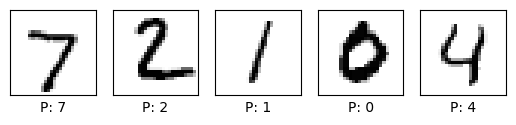

In [ ]:
# Evaluar la exactitud (accuracy)
test_loss, test_acc = model.evaluate(test_data, test_labels, verbose=2)
print(f'\nExactitud en el conjunto de prueba: {test_acc:.4f}')

# Realizar 5 predicciones con datos de prueba
predictions = model.predict(test_data)

print("\n--- Resultados de 5 predicciones ---")
for i in range(5):
    # La predicción con mayor probabilidad
    predicted_label = np.argmax(predictions[i])
    true_label = test_labels[i]

    print(f"Predicción {i+1}: Valor Predicho = {predicted_label} | Valor Real = {true_label}")

    # Opcional: Mostrar la imagen para verificar visualmente
    plt.subplot(1, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(test_data[i], cmap=plt.cm.binary)
    plt.xlabel(f"P: {predicted_label}")

plt.show()